# Introduction to NLP fundamentals in TensorFlow

NLP has the goal of deriving information out of natural language (could be sequences text or speech).

Another common term for NLP problems is sequence to sequence problems (seq2seq).

# Get helper functions

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

# Import series of helper functions for the notebook
from helper_functions import unzip_data , create_tensorboard_callback , plot_loss_curves , compare_historys

--2026-05-30 11:24:25--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-05-30 11:24:25 (77.9 MB/s) - ‘helper_functions.py’ saved [10246/10246]



# Get a text dataset

The dataset we're going to be using is Kaggle's introduction to NLP dataset (text samples of Tweets labelled as disaster or not disaster).

See the original source here: https://www.kaggle.com/competitions/nlp-getting-started

In [ ]:
!wget https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip

# unzip data
unzip_data("nlp_getting_started.zip")

--2026-05-30 11:24:37--  https://storage.googleapis.com/ztm_tf_course/nlp_getting_started.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.130.207, 74.125.68.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.130.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 607343 (593K) [application/zip]
Saving to: ‘nlp_getting_started.zip’

nlp_getting_started 100%[===================>] 593.11K   570KB/s    in 1.0s    

2026-05-30 11:24:39 (570 KB/s) - ‘nlp_getting_started.zip’ saved [607343/607343]



# Visualizing a text dataset

In [ ]:
import pandas as pd
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
# Shuffle training dataframe
train_df_shuffled = train_df.sample(frac = 1 , random_state=42)
train_df_shuffled.head()

,id,keyword,location,text,target
2644,3796,destruction,NaN,So you have a new weapon that can cause un-ima...,1
2227,3185,deluge,NaN,The f$&amp;@ing things I do for #GISHWHES Just...,0
5448,7769,police,UK,DT @georgegalloway: RT @Galloway4Mayor: ÛÏThe...,1
132,191,aftershock,NaN,Aftershock back to school kick off was great. ...,0
6845,9810,trauma,"Montgomery County, MD",in response to trauma Children of Addicts deve...,0


In [ ]:
# What does the test dataframe look like ?
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [ ]:
# How many examples of each class ?
train_df.target.value_counts()

,count
target,
0,4342
1,3271


In [ ]:
# How many total samples ?
len(train_df) , len(test_df)

(7613, 3263)

In [ ]:
# Let's visualize some random training examples
import random
random_index = random.randint(0 , len(train_df)-5) # create random indexes not higher than the total number of examples
for row in train_df_shuffled[["text" , "target"]][random_index : random_index + 5].itertuples():
  _, text , target = row
  print(f"Target: {target}" , "{real disaster}" if target > 0 else "{not real disaster}")
  print(f"Text:\n{text}\n")
  print("---\n")

Target: 0 {not real disaster}
Text:
#golf McIlroy fuels PGA speculation after video: Injured world number one Rory McIlroy fueled speculatio... http://t.co/dCyYJVmXHR #news

---

Target: 0 {not real disaster}
Text:
@HoneyBunzGem @primalkitchen I feel like me doing a pull-up is one of the stages of the Apocalypse.

---

Target: 1 {real disaster}
Text:
@tuicruises @aida_de Cruise Industry Supports Mass Murder of Whales in #Faroe Islands!! 'Everything the (cont) http://t.co/3a3FGZFmzh

---

Target: 0 {not real disaster}
Text:
Evacuate from your life.

---

Target: 0 {not real disaster}
Text:
michael is engulfed by that jumper

---



# Split data into training and validation sets

In [ ]:
from sklearn.model_selection import train_test_split

# Use train_test_split to split training data into training and validation sets
train_sentences , val_sentences , train_labels , val_labels = train_test_split(train_df_shuffled["text"].to_numpy(),
                                                                               train_df_shuffled["target"].to_numpy(),
                                                                               test_size = 0.1, # use 10% of training data for validation
                                                                               random_state=42)

In [ ]:
# Check the lengths
len(train_sentences) , len(train_labels) , len(val_sentences) , len(val_labels)

(6851, 6851, 762, 762)

In [ ]:
# Check the first 10 samples
train_sentences[:10] , train_labels[:10]

(array(['@mogacola @zamtriossu i screamed after hitting tweet',
        'Imagine getting flattened by Kurt Zouma',
        '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
        "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
        'Somehow find you and I collide http://t.co/Ee8RpOahPk',
        '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
        'destroy the free fandom honestly',
        'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
        '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
        'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
       dtype=object),
 array([0,

# Converting text into numbers

When dealing with a text problem, one of the first things you'll have to do before you can build a model is to convert your text to numbers.

There are a few ways to do this, namely:
* Tokenization - direct mapping of token (a token could be a word or a character) to number
* Embedding - create a matrix of feature vector for each token (the size of the feature vector can be defined and this embedding can be learned)

# Text vectorization (tokenization)

In [ ]:
train_sentences[:5]

array(['@mogacola @zamtriossu i screamed after hitting tweet',
       'Imagine getting flattened by Kurt Zouma',
       '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
       "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
       'Somehow find you and I collide http://t.co/Ee8RpOahPk'],
      dtype=object)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

# Use the default TextVecotrization parameters
text_vectorizer = TextVectorization(max_tokens = None, # How many words in the vocabulary (automatically add <oov>)
                                    standardize = "lower_and_strip_punctuation",
                                    split = "whitespace",
                                    ngrams = None, # Create groups of n-words?
                                    output_mode = "int", # How to map tokens to numbers
                                    output_sequence_length = None) # How long do you want your sequence to be?
                                    #pad_to_max_tokens = True)

In [ ]:
len(train_sentences[0].split())

7

In [ ]:
# Find the average number of tokens (words) in the training tweets
round(sum([len(i.split()) for i in train_sentences]) / len(train_sentences))

15

In [ ]:
# Setup text vectorization variables
max_vocab_length = 10000 # max number of words to have in our vocabulary
max_length = 15 # max length our sequences will be (e.g how many words from a Tweet does a model see?)

text_vectorizer = TextVectorization(max_tokens = max_vocab_length,
                                    output_mode = "int",
                                    output_sequence_length = max_length)

In [ ]:
# Fit the text vectorizer to the training text
text_vectorizer.adapt(train_sentences)

In [ ]:
# Create a sample sentence and tokenize it
sample_sentence = "There's a flood in my street !"
text_vectorizer([sample_sentence])

<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[264,   3, 232,   4,  13, 698,   0,   0,   0,   0,   0,   0,   0,
          0,   0]])>

In [ ]:
# Choose a random sentence from the training dataset and tokenize it
random_sentence = random.choice(train_sentences)
print(f"Original text:\n{random_sentence}\
        \n\nVectorized version:")
text_vectorizer([random_sentence])

Original text:
CLEARED:incident with injury:I-495  inner loop Exit 31 - MD 97/Georgia Ave Silver Spring        

Vectorized version:


<tf.Tensor: shape=(1, 15), dtype=int64, numpy=
array([[4001,   14, 2423, 1655, 2062, 1681, 1563, 1814, 2578, 1094, 1112,
        1110,    0,    0,    0]])>

In [ ]:
# Get the unique words in the vocabulary
words_in_vocab = text_vectorizer.get_vocabulary() # get all of the unique words in our training data
top_5_words = words_in_vocab[:5] # get the most common words
bottom_5_words = words_in_vocab[-5:] # get the least common words
print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"5 most common words: {top_5_words}")
print(f"5 least common words: {bottom_5_words}")

Number of words in vocab: 10000
5 most common words: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('in')]
5 least common words: [np.str_('pages'), np.str_('paeds'), np.str_('pads'), np.str_('padres'), np.str_('paddytomlinson1')]


# Creating an Embedding using an Embedding Layer

To make our embedding, we're going to use TensorFlow's embedding layer: https://www.tensorflow.org/text/guide/word_embeddings

The parameters we care most about for our embedding layer:
* `input_dim` = the size of our vocabulary
* `output_dim` = the size of the output embedding vector , for example, a value of 100 would mean each token gets represented by a vector 100 long
* `input_length` = length of the sequences being passed to the embedding layer

In [ ]:
from tensorflow.keras import layers

embedding = layers.Embedding(input_dim = max_vocab_length, #set input shape
                             output_dim = 128, # output shape
                             embeddings_initializer = "uniform",
                             input_length = max_length # how long is each input
                             )
embedding

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [ ]:
# Get a random sentence from the training set
random_sentence = random.choice(train_sentences)
print(f"Original text: \n{random_sentence}\
      \n\nEmbedded version:")

# Embed the random sentence (turn it into dense vectors of fixed size)
sample_embed = embedding(text_vectorizer([random_sentence]))
sample_embed

Original text: 
I'm gunning down romance
It never did a thing for me
But heartache and misery
Ain't nothing but a tragedy http://t.co/jhUPOgbvs8      

Embedded version:


<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[-0.00858583, -0.01398412, -0.00135298, ...,  0.00858972,
         -0.02734768,  0.01858108],
        [-0.02382405,  0.04778569, -0.01228004, ...,  0.04193992,
         -0.02708775, -0.00077938],
        [ 0.02569381,  0.02847004,  0.01716859, ...,  0.01080482,
         -0.03175744,  0.01173528],
        ...,
        [-0.02382405,  0.04778569, -0.01228004, ...,  0.04193992,
         -0.02708775, -0.00077938],
        [-0.04991014, -0.03048806,  0.04060524, ..., -0.0436563 ,
         -0.007858  ,  0.03662277],
        [-0.0097777 ,  0.02993906,  0.01761832, ..., -0.02502284,
         -0.04727285,  0.0038318 ]]], dtype=float32)>

In [ ]:
# Check out a single token's embedding
sample_embed[0][0] , sample_embed[0][0].shape , random_sentence

(<tf.Tensor: shape=(128,), dtype=float32, numpy=
 array([-0.00858583, -0.01398412, -0.00135298, -0.00739814,  0.00381224,
        -0.01596198,  0.00921778, -0.02724333,  0.03731341, -0.04352888,
         0.04118035, -0.00422699,  0.00779847,  0.01791069,  0.04074815,
         0.01017219, -0.0373009 , -0.04290364, -0.01120715,  0.03391022,
         0.01167269,  0.01634413,  0.00246336, -0.01624871, -0.03177754,
        -0.01780499,  0.02618413, -0.02094023, -0.0440172 , -0.01914324,
         0.0334681 ,  0.04022897,  0.03632135, -0.01664367, -0.00119064,
        -0.04028893, -0.00630809,  0.03840203,  0.01047403,  0.01494012,
        -0.00795987, -0.04209187, -0.01329041, -0.02335478,  0.00505364,
         0.02376943,  0.02127181,  0.01909384, -0.00223129,  0.00401885,
         0.02471672, -0.02378696, -0.00465972, -0.04928   ,  0.01664558,
         0.03978601, -0.00822129, -0.03346789,  0.02666104,  0.00635245,
        -0.03163471,  0.00754445,  0.02255941,  0.03850546,  0.02949995,
  

# Modelling a text dataset (running a series of experiments)

Now we've got a way to turn our text sequences into numbers, it's time to start building a series of modelling experiments.

We'll start with a baseline and move on from there.

* Model 0: Naive Bayes (baseline), this is from Sklearn ML map: https://scikit-learn.org/stable/machine_learning_map.html
* Model 1: Feed-forward neural network (dense model)
* Model 2: LSTM model (RNN)
* Model 3: GRU model (RNN)
* Model 4: Bidirectional-LSTM model (RNN)
* Model 5: 1D Convolutional Neural Network (CNN)
* Model 6: TensorFlow Hub Pretrained feature Extractor (using transfer learning for NLP)
* Model 7: Same as model 6 with 10% of training data

How are we going to approach all of these?

Use the standard steps in modelling with tensorflow:

* Create a model
* Build a model
* Fit a model
* Evaluate our model

# Model 0: Getting a baseline

As with all machine learning modelling experiments, it's important to create a baseline model so you've got a benchmark for future experiments to build upon.

To create our baseline, we'll use Sklearn's Multinomial Naive Bayes using TF-IDF formula to convert our words to numbers.

**Note:** It's common practice to use non-DL algorithms as a baseline because of their speed and then later using DL to see if you can improve upon them.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling pipeline
model_0 = Pipeline([
    ("tfidf" , TfidfVectorizer()) , # Convert words to numbers using tfidf
    ("clf" , MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(train_sentences , train_labels)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [ ]:
# Evaluate our baseline model
baseline_score = model_0.score(val_sentences , val_labels)
print(f"Our baseline model achieves an accuracy of: {baseline_score*100:.2f}%")

Our baseline model achieves an accuracy of: 79.27%


In [ ]:
# Make predictions
baseline_preds = model_0.predict(val_sentences)
baseline_preds[:20]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

# Creating an evaluation function for our model experiments

We could evaluate all of our model's predictions with different metrics every time, however, this will be cumbersome and could easily be fixed with a function...

Let's create one to compare our model's predictions with the truth labels using the following metrics:
* Accuracy
* Precision
* Recall
* F1-score

>For a deep overview of many different evaluation methods, see the Sklearn documentation: https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
# Function to evaluate: accuracy, precision, recall, f1-score
from sklearn.metrics import accuracy_score , precision_recall_fscore_support

def calculate_results(y_true , y_pred):
  """

  Calculates model accuracy, precision , recall and f1 score of a binary classification model
  """
  # Calculate model accuracy
  model_accuracy = accuracy_score(y_true , y_pred) * 100
  # Calculate model precision , recall and f1-score using "Weighted" average
  model_precision , model_recall , model_f1, _ = precision_recall_fscore_support(y_true , y_pred , average  = "weighted")
  model_results = {"accuracy" : model_accuracy ,
                   "precision" : model_precision ,
                   "recall" : model_recall ,
                   "f1" : model_f1}
  return model_results

In [ ]:
#Get baseline results
baseline_results = calculate_results(y_true = val_labels,
                                     y_pred = baseline_preds)
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

# Model 1: A simple dense model

In [ ]:
# Create a tensorboard callback (need to create a new one for each model)
from helper_functions import create_tensorboard_callback

# Create a directory to save TensorBoard logs
SAVE_DIR = "model_logs"

In [ ]:
from tensorflow.keras import layers
inputs = layers.Input(shape = (1,) , dtype = tf.string)# inputs are 1-dimensional strings
x = text_vectorizer(inputs) # turn the input text into numbers
x = embedding(x) # create an embedding of the numberized inputs
x = layers.GlobalAveragePooling1D()(x) # Aggregate the sequence dimension
outputs = layers.Dense(1 , activation = "sigmoid")(x) # Create the output layer, want binary outputs so use sigmoid activation function
model_1 = tf.keras.Model(inputs , outputs , name = "model_1_dense")

In [ ]:
model_1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,129 (4.88 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model_1.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
# Fit the model
model_1_history = model_1.fit(x = train_sentences,
                              y = train_labels,
                              epochs = 5,
                              validation_data = (val_sentences , val_labels),
                              callbacks = [create_tensorboard_callback(dir_name = SAVE_DIR,
                                                                       experiment_name = "model_1_dense")])

Saving TensorBoard log files to: model_logs/model_1_dense/20260530-112446
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6878 - loss: 0.6129 - val_accuracy: 0.7677 - val_loss: 0.5375
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8171 - loss: 0.4471 - val_accuracy: 0.7861 - val_loss: 0.4743
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8591 - loss: 0.3532 - val_accuracy: 0.7913 - val_loss: 0.4604
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8873 - loss: 0.2903 - val_accuracy: 0.7887 - val_loss: 0.4677
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9101 - loss: 0.2433 - val_accuracy: 0.7887 - val_loss: 0.4851


In [ ]:
# Check the results
model_1.evaluate(val_sentences , val_labels)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7887 - loss: 0.4851


[0.4851466715335846, 0.7887139320373535]

In [ ]:
# Make some predictions and evaluate those
model_1_pred_probs = model_1.predict(val_sentences)
model_1_pred_probs.shape

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


(762, 1)

In [ ]:
model_1_pred_probs[0]

array([0.30772606], dtype=float32)

In [ ]:
# Look at the first 10 predictions
model_1_pred_probs[:10]

array([[0.30772606],
       [0.7772334 ],
       [0.9977986 ],
       [0.07611463],
       [0.11458943],
       [0.9254324 ],
       [0.8485905 ],
       [0.99259055],
       [0.95088744],
       [0.18297753]], dtype=float32)

In [ ]:
# Convert model prediction probabilities to label format
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))
model_1_preds[:20]

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0.,
       0., 0., 0.], dtype=float32)>

In [ ]:
# Calculate our model_1 results
model_1_results = calculate_results(y_true = val_labels,
                                    y_pred = model_1_preds)
model_1_results

{'accuracy': 78.87139107611549,
 'precision': 0.7975437468825353,
 'recall': 0.7887139107611548,
 'f1': 0.7845609441537968}

In [ ]:
baseline_results

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

In [ ]:
import numpy as np
np.array(list(model_1_results.values())) > np.array(list(baseline_results.values()))

array([False, False, False, False])

# Visualizing learned embeddings

In [ ]:
# Get the vocabulary from the text vectorization layer
words_in_vocabs = text_vectorizer.get_vocabulary()
len(words_in_vocab) , words_in_vocab[:10]

(10000,
 ['',
  '[UNK]',
  np.str_('the'),
  np.str_('a'),
  np.str_('in'),
  np.str_('to'),
  np.str_('of'),
  np.str_('and'),
  np.str_('i'),
  np.str_('is')])

In [ ]:
# Model 1 summary
model_1.summary()

Model: "model_1_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,389 (14.65 MB)

 Trainable params: 1,280,129 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,560,260 (9.77 MB)

In [ ]:
# Get the weight matrix of embedding layer
# (these are the numerical representations of each token in our training data, which have been learned for -5 epochs)
embed_weights = model_1.get_layer("embedding").get_weights()[0]
embed_weights.shape # Same size as vocab size and embedding_dim (output_dim of our embedding layer)

(10000, 128)

Now we've got the embedding matrix our model has learned to represent our tokens, let's see how we can visualize it.

To do so, TensorFlow has a handy tool called projector: http://projector.tensorflow.org/

And TensorFlow also has an incredible guide on word embeddings themselves: https://www.tensorflow.org/text/guide/word_embeddings

In [ ]:
# Create embedding files (we got this from TensorFlow's word embeddings documentation)
# import io
# out_v = io.open('vectors.tsv', 'w', encoding='utf-8')
# out_m = io.open('metadata.tsv', 'w', encoding='utf-8')

# for index, word in enumerate(words_in_vocabs):
#   if index == 0:
#     continue  # skip 0, it's padding.
#   vec = embed_weights[index]
#   out_v.write('\t'.join([str(x) for x in vec]) + "\n")
#   out_m.write(word + "\n")
# out_v.close()
# out_m.close()

In [ ]:
# Download files from colab to upload to projector
# try:
#   from google.colab import files
#   files.download('vectors.tsv')
#   files.download('metadata.tsv')
# except Exception:
#   pass

# Recurrent Neural Networks (RNN's)

RNN's are useful for sequence data.

The promise of a recurrent neural network is to use the representation of a previous input to aid the representation of a later input.

There is an internal of a recurrent neural network:
- chris Olah's intro to LSTMs: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

# Model 2: LSTM

LSTM = long short term memory (one of the most popular LSTM cells)

Our structure of an RNN typically looks like this:

```
Input (text) -> Tokenize -> Embedding -> Layers (RNNs/dense) -> Output (label probability)

In [ ]:
# Create an LSTM model
from tensorflow.keras import layers
inputs = layers.Input(shape = (1,) , dtype = "string")
x = text_vectorizer(inputs)
x = embedding(x)
#print(x.shape)
#x = layers.LSTM(64 , return_sequences = True)(x) # when you're stacking RNN cells together, you need to set return_sequences = True
#print(x.shape)
x = layers.LSTM(64)(x)
#print(x.shape)
#x = layers.Dense(64 , activation = "relu")(x)
#print(x.shape)
outputs = layers.Dense(1 , activation = "sigmoid")(x)
model_2 = tf.keras.Model(inputs , outputs , name = "model_2_LSTM")

In [ ]:
# Get a summary
model_2.summary()

Model: "model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model_2.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
# Fit the model
model_2_history = model_2.fit(train_sentences,
                              train_labels,
                              epochs = 5,
                              validation_data = (val_sentences , val_labels),
                              callbacks = [create_tensorboard_callback(SAVE_DIR,
                                                                       "model_2_LSTM")])

Saving TensorBoard log files to: model_logs/model_2_LSTM/20260530-112458
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9149 - loss: 0.2310 - val_accuracy: 0.7808 - val_loss: 0.5279
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9390 - loss: 0.1593 - val_accuracy: 0.7808 - val_loss: 0.5544
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9491 - loss: 0.1328 - val_accuracy: 0.7808 - val_loss: 0.7877
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9584 - loss: 0.1073 - val_accuracy: 0.7651 - val_loss: 0.7942
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9672 - loss: 0.0870 - val_accuracy: 0.7756 - val_loss: 0.8629


In [ ]:
# Make predictions with LSTM model
model_2_pred_probs = model_2.predict(val_sentences)
model_2_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([[7.8877034e-03],
       [6.1863959e-01],
       [9.9974626e-01],
       [1.3934229e-01],
       [7.5382431e-04],
       [9.9836308e-01],
       [3.6425635e-01],
       [9.9985325e-01],
       [9.9972659e-01],
       [3.9410919e-01]], dtype=float32)

In [ ]:
# Convert model_2 pred probs to labels
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 0., 1., 1., 0.], dtype=float32)>

In [ ]:
# Calculate model 2 results
model_2_results = calculate_results(y_true = val_labels,
                                    y_pred = model_2_preds)
model_2_results

{'accuracy': 77.55905511811024,
 'precision': 0.7783607884132258,
 'recall': 0.7755905511811023,
 'f1': 0.7730920642120305}

# Model 3: GRU

Another popular and effective RNN component is the GRU or gated recurrent unit.

The GRU cell has similar features to an LSTM cell but has less parameters.

In [ ]:
# Build an RNN using the GRU cell
from tensorflow.keras import layers
inputs = layers.Input(shape = (1,) , dtype = "string")
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.GRU(64)(x)
#print(x.shape)
#x = layers.GRU(64 , return_sequences=True)(x) # if you want to stack recurrent layers on top of each other, you need return_sequences = True
# print(x.shape)
# x = layers.LSTM(42 , return_sequences = True)(x)
# print(x.shape)
# x = layers.GRU(99)(x)
# print(x.shape)
x = layers.Dense(64 , activation = "relu")(x)
outputs = layers.Dense(1 , activation = "sigmoid")(x)
model_3 = tf.keras.Model(inputs , outputs , name = "model_3_GRU")

In [ ]:
model_3.summary()

Model: "model_3_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,321,473 (5.04 MB)

 Trainable params: 1,321,473 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model_3.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
# Fit the model
model_3_history = model_3.fit(train_sentences,
                              train_labels,
                              epochs = 5,
                              validation_data = (val_sentences , val_labels),
                              callbacks = [create_tensorboard_callback(SAVE_DIR,
                                                                       "model_3_GRU")])

Saving TensorBoard log files to: model_logs/model_3_GRU/20260530-112510
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9378 - loss: 0.1609 - val_accuracy: 0.7730 - val_loss: 0.7722
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9683 - loss: 0.0850 - val_accuracy: 0.7782 - val_loss: 0.8976
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9727 - loss: 0.0701 - val_accuracy: 0.7703 - val_loss: 0.9843
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9750 - loss: 0.0581 - val_accuracy: 0.7664 - val_loss: 1.1050
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9764 - loss: 0.0546 - val_accuracy: 0.7743 - val_loss: 1.2672


In [ ]:
# Make some predictions with our GRU model
model_3_pred_probs = model_3.predict(val_sentences)
model_3_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([[5.0086004e-04],
       [6.4646417e-01],
       [9.9987411e-01],
       [6.2250149e-02],
       [1.8521025e-05],
       [9.9983859e-01],
       [5.4564399e-01],
       [9.9995863e-01],
       [9.9993455e-01],
       [4.2765367e-01]], dtype=float32)

In [ ]:
#Convert model 3 pred probs to labels
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 0.], dtype=float32)>

In [ ]:
# Calculate model 3 results
model_3_results = calculate_results(y_true = val_labels,
                                    y_pred = model_3_preds)
model_3_results

{'accuracy': 77.42782152230971,
 'precision': 0.7790421904139229,
 'recall': 0.7742782152230971,
 'f1': 0.77094690659836}

# Model 4 : Bidirectional RNN

Normal RNN's go from left to right (just like you'd read an English sentence) however, a bidirectional RNN goes from right to left as well as left to right.

In [ ]:
# Build a bidirectional RNN in TensorFlow
from tensorflow.keras import layers
inputs = layers.Input(shape = (1,) , dtype = tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
# x = layers.Bidirectional(layers.LSTM(64 , return_sequences = True))(x)
# print(x.shape)
x = layers.Bidirectional(layers.LSTM(64))(x)
outputs = layers.Dense(1 , activation = "sigmoid")(x)
model_4 = tf.keras.Model(inputs , outputs , name = "model_4_bidirectional")

In [ ]:
# Get a summary
model_4.summary()

Model: "model_4_bidirectional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model_4.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

In [ ]:
# Fit the model
model_4_history = model_4.fit(train_sentences,
                              train_labels,
                              epochs = 5,
                              validation_data = (val_sentences , val_labels),
                              callbacks = [create_tensorboard_callback(SAVE_DIR,
                                                                       "model_4_bidirectional")])

Saving TensorBoard log files to: model_logs/model_4_bidirectional/20260530-112522
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9609 - loss: 0.1151 - val_accuracy: 0.7769 - val_loss: 0.8262
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9759 - loss: 0.0531 - val_accuracy: 0.7769 - val_loss: 1.1851
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9764 - loss: 0.0535 - val_accuracy: 0.7664 - val_loss: 1.2561
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9784 - loss: 0.0489 - val_accuracy: 0.7743 - val_loss: 1.2864
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9797 - loss: 0.0459 - val_accuracy: 0.7703 - val_loss: 1.3572


In [ ]:
# Make some predictions with our bidirectional model
model_4_pred_probs = model_4.predict(val_sentences)
model_4_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


array([[1.3638118e-02],
       [5.3935653e-01],
       [9.9991894e-01],
       [3.3013669e-01],
       [5.7505160e-05],
       [9.9979490e-01],
       [8.7531787e-01],
       [9.9997866e-01],
       [9.9994588e-01],
       [9.9791700e-01]], dtype=float32)

In [ ]:
# Convert pred probs into labels
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [ ]:
# calculate the results of our bidirectional model
model_4_results = calculate_results(y_true = val_labels,
                                    y_pred = model_4_preds)
model_4_results

{'accuracy': 77.03412073490814,
 'precision': 0.7708102089179978,
 'recall': 0.7703412073490814,
 'f1': 0.7689180260110317}

# Concolutional Neural Networks for Text (and other type of sequences)

We've used CNN's for images but images are typically 2D (height & width)... however, our text data is 1D.

Previously we've used 2D Conv2D for our image data but now we're going to use Conv1D.

The typical structure of a Conv1D model for sequences (in our case, text):

```
Inputs (text) -> Tokenization -> Embedding -> Layer(s) (typically Conv1D + pooling) -> Outputs (class probabilities)
```

# Model 5: Conv1D

For difference explanations of parameters see:
* https://poloclub.github.io/cnn-explainer/ (this is for 2D but can relate for 1D data)
* Difference between "same" and "valid" padding: https://stackoverflow.com/questions/37674306/what-is-the-difference-between-same-and-valid-padding-in-tf-nn-max-pool-of-t


In [ ]:
# Test out our embedding layer, Conv1D layer and max pooling
from tensorflow.keras import layers
embedding_test = embedding(text_vectorizer(["this is a test sentence"])) # turn target sequence into embedding
conv_1d = layers.Conv1D(filters = 32,
                        kernel_size = 5, # this is also referred to as an ngram of 5 (meaning it looks at 5 words at a time)
                        strides = 1, # default
                        activation = "relu",
                        padding = "same") # default = "valid", the output is smaller than the input shape, "same" means output is same shape as input
conv_1d_output = conv_1d(embedding_test) # pass test embedding through conv1d layer
max_pool = layers.GlobalMaxPool1D()
max_pool_output = max_pool(conv_1d_output) # equivalent to "get the most important feature" or "get the feature with the highest value"

embedding_test.shape , conv_1d_output.shape , max_pool_output.shape

(TensorShape([1, 15, 128]), TensorShape([1, 15, 32]), TensorShape([1, 32]))

In [ ]:
embedding_test

<tf.Tensor: shape=(1, 15, 128), dtype=float32, numpy=
array([[[-0.03757552,  0.07416477,  0.03302988, ...,  0.05827574,
         -0.02579655,  0.0067684 ],
        [ 0.0476542 , -0.00212861,  0.0458979 , ...,  0.06979813,
          0.06407407, -0.04629452],
        [-0.05709946,  0.01965259, -0.03731138, ...,  0.05667478,
          0.04323501, -0.0099981 ],
        ...,
        [-0.03044482, -0.00648043, -0.1552122 , ...,  0.00777662,
         -0.00259342,  0.00283792],
        [-0.03044482, -0.00648043, -0.1552122 , ...,  0.00777662,
         -0.00259342,  0.00283792],
        [-0.03044482, -0.00648043, -0.1552122 , ...,  0.00777662,
         -0.00259342,  0.00283792]]], dtype=float32)>

In [ ]:
conv_1d_output

<tf.Tensor: shape=(1, 15, 32), dtype=float32, numpy=
array([[[0.        , 0.        , 0.02735026, 0.        , 0.01076433,
         0.        , 0.00579973, 0.        , 0.01645988, 0.        ,
         0.00272719, 0.        , 0.02486971, 0.00221328, 0.        ,
         0.0135015 , 0.0438104 , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.07124759, 0.00237293, 0.03731844,
         0.        , 0.0218879 , 0.        , 0.        , 0.00574558,
         0.00646167, 0.0342054 ],
        [0.04661877, 0.05654889, 0.00574326, 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.06798767, 0.        , 0.04374941, 0.        , 0.        ,
         0.        , 0.03133346, 0.        , 0.        , 0.09859783,
         0.        , 0.03701518, 0.02790362, 0.02225147, 0.05988345,
         0.        , 0.        , 0.05757836, 0.092072  , 0.        ,
         0.1073001 , 0.11804963],
        [0.        , 0.01555376, 0.02262777, 0.0347

In [ ]:
max_pool_output

<tf.Tensor: shape=(1, 32), dtype=float32, numpy=
array([[0.04661877, 0.05725684, 0.05204948, 0.03474197, 0.11522133,
        0.05080076, 0.08569595, 0.00310326, 0.040006  , 0.        ,
        0.07281598, 0.05919899, 0.04518439, 0.06604135, 0.07151306,
        0.06707266, 0.05247142, 0.03491956, 0.03713323, 0.09859783,
        0.02183354, 0.03701518, 0.07124759, 0.0653885 , 0.07444508,
        0.01917882, 0.0389679 , 0.05959487, 0.092072  , 0.10337459,
        0.1073001 , 0.11804963]], dtype=float32)>

In [ ]:
# Create 1-dimensional convolutional layer to model sequences
from tensorflow.keras import layers
inputs = layers.Input(shape = (1,) , dtype = "string")
x = text_vectorizer(inputs)
x = embedding(x)
x = layers.Conv1D(filters = 64
                  , kernel_size = 2
                  , strides = 1
                  , activation = "relu"
                  , padding = "valid")(x)
x = layers.GlobalMaxPool1D()(x)
#x = layers.Dense(64 , activation = "relu")(x)
outputs = layers.Dense(1 , activation = "sigmoid")(x)
model_5 = tf.keras.Model(inputs , outputs , name = "model_5_Conv1D")

#Compile the model
model_5.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# Get a summary of our Conv1D model
model_5.summary()

Model: "model_5_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 15)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 15, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 14, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,513 (4.95 MB)

 Trainable params: 1,296,513 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
model_5_history = model_5.fit(train_sentences,
                              train_labels,
                              epochs = 5,
                              validation_data = (val_sentences , val_labels),
                              callbacks = [create_tensorboard_callback(SAVE_DIR,
                                                                       "Conv1D")])

Saving TensorBoard log files to: model_logs/Conv1D/20260530-112536
Epoch 1/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9460 - loss: 0.1736 - val_accuracy: 0.7795 - val_loss: 0.7324
Epoch 2/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9609 - loss: 0.1085 - val_accuracy: 0.7677 - val_loss: 0.8438
Epoch 3/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9683 - loss: 0.0807 - val_accuracy: 0.7651 - val_loss: 0.9481
Epoch 4/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9745 - loss: 0.0648 - val_accuracy: 0.7625 - val_loss: 1.0726
Epoch 5/5
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9766 - loss: 0.0566 - val_accuracy: 0.7664 - val_loss: 1.1273


In [ ]:
# Make some predictions with our Conv1D model
model_5_pred_probs = model_5.predict(val_sentences)
model_5_pred_probs[:10]

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


array([[1.9875515e-02],
       [6.6829425e-01],
       [9.9767476e-01],
       [3.5225119e-02],
       [6.0613797e-06],
       [9.8058736e-01],
       [6.1491752e-01],
       [9.9998927e-01],
       [9.9956626e-01],
       [6.4133561e-01]], dtype=float32)

In [ ]:
# Convert model 5 pred probs into labels
model_5_preds = tf.squeeze(tf.round(model_5_pred_probs))
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=float32, numpy=array([0., 1., 1., 0., 0., 1., 1., 1., 1., 1.], dtype=float32)>

In [ ]:
# Evaluate model_5 predictions
model_5_results = calculate_results(y_true = val_labels,
                                    y_pred = model_5_preds)
model_5_results

{'accuracy': 76.64041994750657,
 'precision': 0.7674517658976838,
 'recall': 0.7664041994750657,
 'f1': 0.7645419362124183}

## Model 6: TensorFlow Hub Pretrained Sentence Encoder

Now we've built a few of our own models, let's try and use trainsfer learning for NLP, specificially using TensoFlow Hub's Universal Sentence Encoder: https://tfhub.dev/google/universal-sentence-encoder/4

In [ ]:
sample_sentence

"There's a flood in my street !"

In [ ]:
import tensorflow_hub as hub
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
embed_samples = embed([sample_sentence,
                       "When you can the universal sentence encoder on a sentence, it turns it into numbers."])
print(embed_samples[0][:50])

tf.Tensor(
[-0.01157028  0.0248591   0.02878048 -0.012715    0.03971538  0.0882776
  0.02680984  0.05589836 -0.0106873  -0.00597291  0.00639323 -0.01819518
  0.00030813  0.09105888  0.05874644 -0.03180628  0.01512474 -0.05162929
  0.00991367 -0.06865347 -0.04209306  0.02678981  0.03011006  0.00321069
 -0.00337973 -0.04787357  0.0226672  -0.00985925 -0.04063613 -0.01292092
 -0.04666384  0.05630299 -0.03949255  0.00517686  0.02495829 -0.0701444
  0.02871508  0.04947684 -0.00633979 -0.08960192  0.02807118 -0.00808364
 -0.01360602  0.0599865  -0.10361787 -0.05195374  0.00232954 -0.02332531
 -0.03758105  0.03327728], shape=(50,), dtype=float32)


In [ ]:
embed_samples[0].shape

TensorShape([512])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import tensorflow_hub as hub

# Create a custom Keras layer to wrap the TF Hub Universal Sentence Encoder
class UniversalSentenceEncoderLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(UniversalSentenceEncoderLayer, self).__init__(**kwargs)
        # Instantiate the TF Hub KerasLayer within the custom layer's constructor
        self.encoder = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                      input_shape=[], dtype=tf.string, trainable=False)

    def call(self, inputs):
        # Call the TF Hub KerasLayer's call method
        return self.encoder(inputs)

# Instantiate the custom layer
sentence_encoder_layer = UniversalSentenceEncoderLayer(name="USE")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Create model using the Functional API
inputs = layers.Input(shape = [] , dtype = tf.string)
x = sentence_encoder_layer(inputs)
x = layers.Dense(64 , activation = "relu")(x)
outputs = layers.Dense(1 , activation = "sigmoid" , name = "output_layer")(x)
model_6 = tf.keras.Model(inputs=inputs , outputs=outputs , name = "model_6_USE")

# Compile the model
model_6.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

model_6.summary()

Model: "model_6_USE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ USE                             │ (None, 512)            │             0 │
│ (UniversalSentenceEncoderLayer) │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BATCH_SIZE = 16

In [ ]:
# # Train a classifier on top of USE pretrained embeddings
# model_6_history = model_6.fit(train_sentences,
#                               train_labels,
#                               epochs = 5,
#                               validation_data = (val_sentences , val_labels),
#                               callbacks = [create_tensorboard_callback(SAVE_DIR,
#                                                                        "tf_hub_sentence_encoder")])

In [ ]:
# # Make predictions with USE TF Hub Model
# model_6_pred_probs = model_6.predict(val_sentences)
# model_6_pred_probs[:10]

In [ ]:
# # Convert prediction probabilities to labels
# model_6_preds = tf.squeeze(tf.round(model_6_pred_probs))
# model_6_preds[:10]

In [ ]:
# # Calculate model 6 performance metrics
# model_6_results = calculate_results(y_true = val_labels,
#                                     y_pred = model_6_preds)
# model_6_results

# Model 7: TF Hub Pretrained USE but with 10% of training data

Transfer learning really helps when you don't have a large dataset.

To see how our model performs on a smaller dataset, let's replicate `model_6` except we'll train it on 10% of the data.

In [ ]:
# import numpy as np

# ## NOTE: Making data splits like below leads to data leakage  (model_7 trained on 10% data, outperforms model_6 trained on 100% data)
# ## DO NOT MAKE DATA SPLITS WHICH LEAK DATA FROM VALIDATION/TEST SETS INTO TRAINING SET


# # Create subset of 10% of the training data
# train_10_percent = train_df_shuffled[["text" , "target"]].sample(frac = 0.1 , random_state = 42)
# # train_10_percent.head() , len(train_10_percent)
# train_sentences_10_percent = train_10_percent["text"].to_list()
# train_labels_10_percent = train_10_percent["target"].to_list()
# len(train_sentences_10_percent) , len(train_labels_10_percent)

> 🔑 **Note:** Be *very* careful when creating training/val/test splits that you don't leak data across the datasets, otherwise your model evaluation metrics will be wrong. If something looks too good to be true (a model trained on 10% of data outperforming the same model trained on 100% of data) trust your gut and go back through to find where the error may lie.

In [ ]:
# Making a better dataset split (no data leakage)
train_10_percent_split = int(0.1 * len(train_sentences))
train_sentences_10_percent = train_sentences[:train_10_percent_split]
train_labels_10_percent = train_labels[:train_10_percent_split]
len(train_labels_10_percent)

685

In [ ]:
train_sentences_10_percent[:10]

array(['@mogacola @zamtriossu i screamed after hitting tweet',
       'Imagine getting flattened by Kurt Zouma',
       '@Gurmeetramrahim #MSGDoing111WelfareWorks Green S welfare force ke appx 65000 members har time disaster victim ki help ke liye tyar hai....',
       "@shakjn @C7 @Magnums im shaking in fear he's gonna hack the planet",
       'Somehow find you and I collide http://t.co/Ee8RpOahPk',
       '@EvaHanderek @MarleyKnysh great times until the bus driver held us hostage in the mall parking lot lmfao',
       'destroy the free fandom honestly',
       'Weapons stolen from National Guard Armory in New Albany still missing #Gunsense http://t.co/lKNU8902JE',
       '@wfaaweather Pete when will the heat wave pass? Is it really going to be mid month? Frisco Boy Scouts have a canoe trip in Okla.',
       'Patient-reported outcomes in long-term survivors of metastatic colorectal cancer - British Journal of Surgery http://t.co/5Yl4DC1Tqt'],
      dtype=object)

In [ ]:
len(train_sentences)

6851

In [ ]:
# Check the number of each label in the updated training data subset
pd.Series(np.array(train_labels_10_percent)).value_counts()

,count
0,406
1,279


In [ ]:
# Check the number of targets in our subset of data
train_df_shuffled["target"].value_counts()

,count
target,
0,4342
1,3271


To recreate a model the same as a previous model you've created you can use the `tf.keras.models.clone_model()` method, see more here: https://www.tensorflow.org/api_docs/python/tf/keras/models/clone_model

In [ ]:
# Let's build a model the same as model_6
# model_7 = tf.keras.models.clone_model(model_6)

# Create model using the Functional API
inputs = layers.Input(shape = [] , dtype = tf.string)
x = sentence_encoder_layer(inputs)
x = layers.Dense(64 , activation = "relu")(x)
outputs = layers.Dense(1 , activation = "sigmoid" , name = "output_layer")(x)
model_7 = tf.keras.Model(inputs=inputs , outputs=outputs , name = "model_7_USE")

# Compile the model
model_7.compile(loss = "binary_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics = ["accuracy"])

# Get a summary (will be same as model_6)
model_7.summary()

Model: "model_7_USE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ USE                             │ (None, 512)            │             0 │
│ (UniversalSentenceEncoderLayer) │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model_7_history = model_7.fit(train_sentences_10_percent,
#                               train_labels_10_percent,
#                               epochs = 5,
#                               batch_size=BATCH_SIZE,
#                               validation_data = (val_sentences , val_labels),
#                               callbacks = [create_tensorboard_callback(SAVE_DIR,
#                                                                        "tf_hub_sentence_encoder_10_percent_correct_split")])

In [ ]:
# # Make some predictions wi the model trained on 10% of the data
# model_7_pred_probs = model_7.predict(val_sentences)
# model_7_pred_probs[:10]

In [ ]:
# # Turn pred probs into labels
# model_7_preds = tf.squeeze(tf.round(model_7_pred_probs))
# model_7_preds[:10]

In [ ]:
# # Evaluate model 7 predictions
# model_7_results = calculate_results(y_true = val_labels,
#                                     y_pred = model_7_preds)
# model_7_results

## Comparing the performance of each of our models


In [ ]:
# Combine model results into a DataFrame
import pandas as pd

all_model_results = pd.DataFrame({"0_baseline" : baseline_results,
                                  "1_simple_dense" : model_1_results,
                                  "2_lstm" : model_2_results,
                                  "3_gru" : model_3_results,
                                  "4_bidirectional" : model_4_results,
                                  "5_conv1d" : model_5_results
                                  #"6_tf_hub_use_encoder" : model_6_results,
                                  #"7_tf_hub_use_encoder_10%" : model_7_results
                                  })
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
0_baseline,79.265092,0.811139,0.792651,0.786219
1_simple_dense,78.871391,0.797544,0.788714,0.784561
2_lstm,77.559055,0.778361,0.775591,0.773092
3_gru,77.427822,0.779042,0.774278,0.770947
4_bidirectional,77.034121,0.770810,0.770341,0.768918
5_conv1d,76.640420,0.767452,0.766404,0.764542


In [ ]:
# Reduce the accuracy to the same scale as other metrics
all_model_results["accuracy"] = all_model_results["accuracy"] / 100
all_model_results

,accuracy,precision,recall,f1
0_baseline,0.792651,0.811139,0.792651,0.786219
1_simple_dense,0.788714,0.797544,0.788714,0.784561
2_lstm,0.775591,0.778361,0.775591,0.773092
3_gru,0.774278,0.779042,0.774278,0.770947
4_bidirectional,0.770341,0.770810,0.770341,0.768918
5_conv1d,0.766404,0.767452,0.766404,0.764542


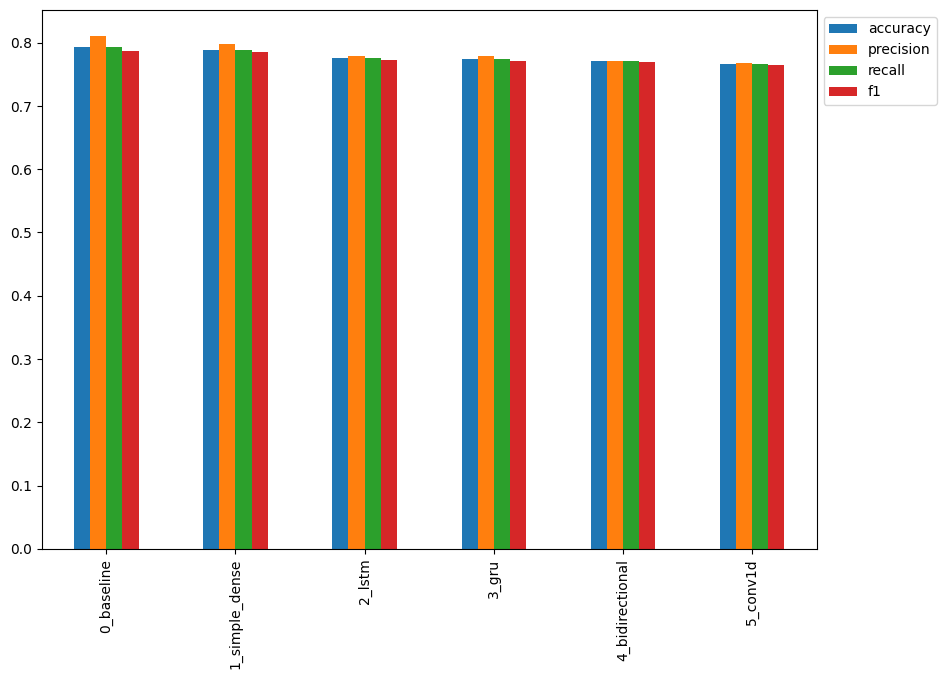

In [ ]:
# Plot and compare all of the model results
import matplotlib.pyplot as plt

all_model_results.plot(kind = "bar" , figsize = (10 , 7)).legend(bbox_to_anchor = (1.0 , 1.0));

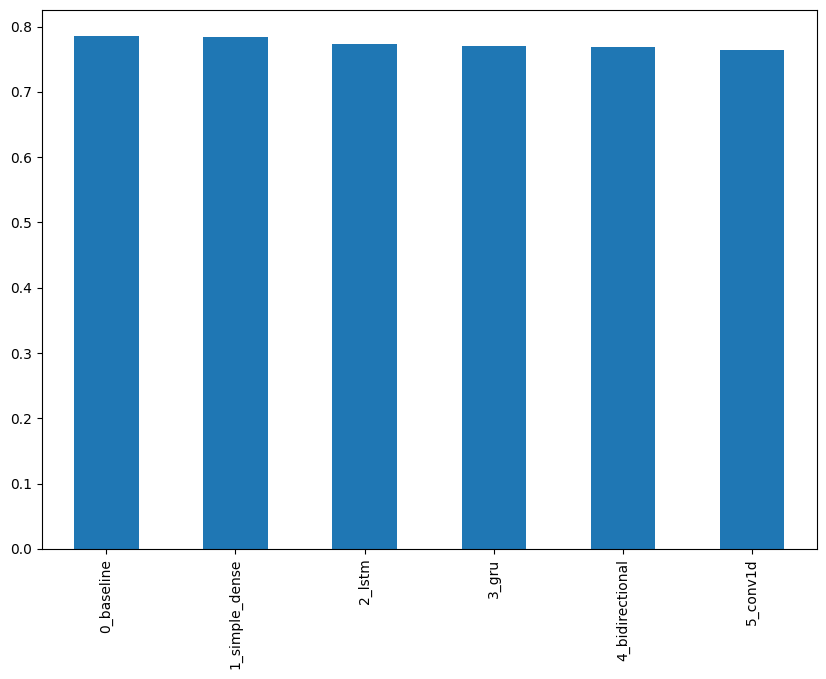

In [ ]:
# Sort model results by f1-scores
all_model_results.sort_values("f1" , ascending = False)["f1"].plot(kind = "bar" , figsize = (10 , 7));

# Uploading our model training logs to TensorBoard.dev

We can further inspect our model's performance using TensorBoard.dev: https://tensorboard.dev/

In [ ]:
# View TensorBoard logs of transfer learning modelling experiments (plus all of our other models)
# Upload TensoBoard dev records
!tensorboard dev upload --logdir ./model_logs/ \
  --name "NLP Modelling Experiments Bashar.Dandan TF Course" \
  --description "Comparing multiple different types of model architectures on the Kaggle Tweets text classification dataset" \
  --one_shot # exit the uploader once uploading is finished

ERROR: The `tensorboard dev` command is no longer available.

TensorBoard.dev has been shut down. For further information,
see the FAQ at <https://tensorboard.dev/>.


In [ ]:
# # See the previous TensorBoard Dev experiments you've run...
# !tensorboard dev list

In [ ]:
# If you need to delete an experiment from TensorBoard, you can run the following:
# !tensorboard dev delete --experiment_id

## Saving and loading a trained model

There are two main formats to save a model to in TensorFlow:
1. The HDF5 format
2. The `SavedModel` format (this is the default when using TensorFlow)

In [ ]:
# Save TF Hub Sentence Encoder model to HDF5 format , but we will save our base_line trained model (model_0) because of the crash of (model 6 & 7)
import joblib

# Save the baseline trained model (model_0) using joblib
joblib.dump(model_0, "model_0.joblib")

['model_0.joblib']

In [ ]:
# # Load model with custom Hub Layer (required HDF5 format)
# import tensorflow_hub as hub
# loaded_model_0 = tf.keras.models.load_model("model_0.joblib",
#                                             custom_objects = {"Keraslayer" : hub.KerasLayer})
import joblib

# Load the baseline trained model (model_0)
loaded_model_0 = joblib.load("model_0.joblib")

In [ ]:
# How does our loaded model perform ?
loaded_model_0_preds = loaded_model_0.predict(val_sentences)
loaded_model_0_results = calculate_results(y_true=val_labels, y_pred=loaded_model_0_preds)
display(loaded_model_0_results)

{'accuracy': 79.26509186351706,
 'precision': 0.8111390004213173,
 'recall': 0.7926509186351706,
 'f1': 0.7862189758049549}

Now let's save the `SavedModel` format...(see more on this here: https://www.tensorflow.org/tutorials/keras/save_and_load)

* Same as the previous step **HDF5 format**

## Finding the most wrong examples

* If our best model still isn't perfect, what examples is it getting wrong?
* And of these wrong examples which ones is it getting *most* wrong (those will prediction probabilities closest to the opposite class)

For example if a sample should have a label of 0 but our model predicts a prediction probability 0f 0.999 (really close to 1) and vice versa.

In [ ]:
# Download a pretrained model from Google Storage
!wget https://storage.googleapis.com/ztm_tf_course/08_model_6_USE_feature_extractor.zip
!unzip 08_model_6_USE_feature_extractor.zip

--2026-05-30 11:27:04--  https://storage.googleapis.com/ztm_tf_course/08_model_6_USE_feature_extractor.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.200.207, 74.125.130.207, 74.125.68.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.200.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 960779165 (916M) [application/zip]
Saving to: ‘08_model_6_USE_feature_extractor.zip’

08_model_6_USE_feat 100%[===================>] 916.27M  18.3MB/s    in 55s     

2026-05-30 11:28:00 (16.7 MB/s) - ‘08_model_6_USE_feature_extractor.zip’ saved [960779165/960779165]

Archive:  08_model_6_USE_feature_extractor.zip
   creating: 08_model_6_USE_feature_extractor/
   creating: 08_model_6_USE_feature_extractor/assets/
   creating: 08_model_6_USE_feature_extractor/variables/
  inflating: 08_model_6_USE_feature_extractor/variables/variables.data-00000-of-00001  
  inflating: 08_model_6_USE_feature_extractor/variables/variables.in

In [ ]:
# # Import previously trained model from Google Storage
# model_6_pretrained = tf.keras.models.load_model("08_model_6_USE_feature_extractor")
# model_6_pretrained.evaluate(val_sentences , val_labels)

In [ ]:
# # Make some predictions with the loaded model from GS
# model_6_pretrained_pred_probs = model_6_pretrained.predict(val_sentences)
# model_6_pretrained_preds = tf.squeeze(tf.round(model_6_pretrained_pred_probs))
# model_6_pretrained_preds[:10]

In [ ]:
# # Create DataFrame with validation sentences, validation labels and best performing model prediction labels + probabilities
# val_df = pd.DataFrame({"text" : val_sentences,
#                        "target" : val_labels,
#                        "pred" : model_6_pretrained_preds,
#                        "pred_probs" : tf.squeeze(model_6_pretrained_pred_probs)})

# val_df.head()

In [ ]:
# # Find the wrong predictions and sort by prediction probabilities
# most_wrong = val_df["target"] != val_df["pred"].sort_values("pred_prob" , ascending = False)
# most_wrong

Let's remind ourselves of the target labels...

* 0 = not disaster
* 1 = disaster

In [ ]:
# # Check the false positives (model predicted 1 when should've been 0)
# for row in most_wrong[:10].itertuples():
#   _, text , target , pred , pred_probs = row

#   print(f"Target: {target} , Pred: {pred} , Prob: {pred_probs}")
#   print(f"Text:\n{text}\n")
#   print("----\n")

In [ ]:
# # Check the false negatives (model predicted 0 when should've been 1)
# for row in most_wrong[-10:].itertuples():
#   _, text , target , pred , pred_probs = row

#   print(f"Target: {target} , Pred: {pred} , Prob: {pred_probs}")
#   print(f"Text:\n{text}\n")
#   print("----\n")

## Making predictions on the test dataset

In [ ]:
# # Making predictions on the test dataset and visualizing them
# test_sentences = test_df["text"].to_list()
# test_samples = random.sample(test_sentences , 10)
# for test_samples in test_samples:
#   pred_prob = tf.squeeze(model_6_pretrained.predict([test_samples])) # our model expects a list as input
#   pred = tf.round(pred_prob)
#   print(f"Pred: {int(pred)} , Prob: {pred_prob}")
#   print(f"Text:\n{test_samples}\n")
#   print("----\n")

# The speed/tradeoff

In [ ]:
# Let's make a function to measure the time of prediction
import time
def pred_timer(model , samples):
  """
  Times how long a model takes to make predictions on samples.

  """
  start_time = time.perf_counter() # get start time
  model.predict(samples) # make predictions
  end_time = time.perf_counter() # get finish time
  total_time = end_time - start_time # calculate how long predictions took to make
  time_per_pred = total_time / len(samples)
  return total_time , time_per_pred

In [ ]:
# # Calculate TF Hub Sentence Encoder time per pred
# model_6_total_pred_time , model_6_time_per_pred = pred_timer(model = model_6_pretrained,
#                                                              samples = val_sentences)
# model_6_total_pred_time , model_6_time_per_pred

In [ ]:
# Calculate our baseline model times per pred
baseline_total_pred_time , baseline_time_per_pred = pred_timer(model = model_0,
                                                               samples = val_sentences)
baseline_total_pred_time , baseline_time_per_pred

(0.04550976400059881, 5.9724099738318644e-05)

In [ ]:
# # Get results for pretrained GS model
# model_6_pretrained_results = calculate_results(y_true = val_labels,
#                                                y_pred = model_6_pretrained_preds)
# model_6_pretrained_results

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize = (10 , 7))
# plt.scatter(baseline_time_per_pred , baseline_results["f1"] , label = "baseline")
# plt.scatter(model_6_time_per_pred , model_6_pretrained_results["f1"] , label = "tf_hub_sentence_encoder")
# plt.legend()
# plt.title("F1-score versus time per prediction")
# plt.xlabel("Time per prediction")
# plt.ylabel("F1-score");